# 1. Tổng quan cấu trúc

Dataset gồm 15 bảng, chia thành 4 nhóm:

* **Master**: dữ liệu danh mục (dimension tables)
* **Transaction**: dữ liệu giao dịch (fact tables chi tiết)
* **Analytical**: dữ liệu tổng hợp phục vụ modeling
* **Operational**: dữ liệu vận hành (hỗ trợ phân tích nâng cao)

---

# 2. Chi tiết từng bảng

## I. MASTER TABLES

### 1. `products.csv`

**Thông tin sản phẩm**

* **PK**: `product_id`

**Thuộc tính:**

* product_name
* category
* segment
* size
* color
* price (giá bán)
* cogs (giá vốn)

**Ràng buộc:**

$$
\text{cogs} < \text{price}
$$

---

### 2. `customers.csv`

**Thông tin khách hàng**

* **PK**: `customer_id`
* **FK**: `zip \rightarrow geography.zip`

**Thuộc tính:**

* city
* signup_date
* gender *(nullable)*
* age_group *(nullable)*
* acquisition_channel *(nullable)*

---

### 3. `promotions.csv`

**Thông tin khuyến mãi**

* **PK**: `promo_id`

**Thuộc tính:**

* promo_name
* promo_type *(percentage / fixed)*
* discount_value
* start_date, end_date
* applicable_category *(nullable)*
* promo_channel *(nullable)*
* stackable_flag
* min_order_value *(nullable)*

**Công thức giảm giá:**

$$
\text{Discount}_{%} = q \times p \times \frac{d}{100}
$$

$$
\text{Discount}_{fixed} = q \times d
$$

---

### 4. `geography.csv`

* **PK**: `zip`

**Thuộc tính:**

* city
* region
* district

---

## II. TRANSACTION TABLES

### 5. `orders.csv`

**Thông tin đơn hàng**

* **PK**: `order_id`

**FK:**

* `customer_id \rightarrow customers`
* `zip \rightarrow geography`

**Thuộc tính:**

* order_date
* order_status
* payment_method
* device_type
* order_source

---

### 6. `order_items.csv`

**Chi tiết sản phẩm trong đơn**

**FK:**

* `order_id \rightarrow orders`
* `product_id \rightarrow products`
* `promo_id \rightarrow promotions` *(nullable)*
* `promo_id_2 \rightarrow promotions` *(nullable)*

**Thuộc tính:**

* quantity
* unit_price
* discount_amount

👉 *Granularity thấp nhất (line-item level)*

---

### 7. `payments.csv`

* **PK & FK**: `order_id \rightarrow orders` *(1:1)*

**Thuộc tính:**

* payment_method
* payment_value
* installments

---

### 8. `shipments.csv`

* **FK**: `order_id \rightarrow orders`

**Thuộc tính:**

* ship_date
* delivery_date
* shipping_fee

👉 Chỉ tồn tại nếu:

* shipped / delivered / returned

---

### 9. `returns.csv`

* **PK**: `return_id`

**FK:**

* `order_id \rightarrow orders`
* `product_id \rightarrow products`

**Thuộc tính:**

* return_date
* return_reason
* return_quantity
* refund_amount

👉 Một đơn có thể có nhiều dòng return

---

### 10. `reviews.csv`

* **PK**: `review_id`

**FK:**

* `order_id \rightarrow orders`
* `product_id \rightarrow products`
* `customer_id \rightarrow customers`

**Thuộc tính:**

* review_date
* rating $(1-5)$
* review_title

👉 Khoảng 20% đơn có review

---

## III. ANALYTICAL TABLES

### 11. `sales.csv`

**Dữ liệu tổng hợp theo ngày**

**Thuộc tính:**

* Date
* Revenue
* COGS

👉 Dùng để train forecasting model

---

### 12. `sales_test.csv`

* Không public
* Dùng để chấm điểm

---

### 13. `sample_submission.csv`

* Format nộp bài

---

## IV. OPERATIONAL TABLES

### 14. `inventory.csv`

**Tồn kho theo tháng**

* **FK**: `product_id \rightarrow products`
* **Granularity**: product $\times$ month

**Thuộc tính:**

* snapshot_date
* stock_on_hand
* units_received
* units_sold
* stockout_days
* days_of_supply
* fill_rate
* stockout_flag
* overstock_flag
* reorder_flag
* sell_through_rate
* category, segment
* year, month

---

### 15. `web_traffic.csv`

**Lưu lượng web theo ngày**

**Thuộc tính:**

* date
* sessions
* unique_visitors
* page_views
* bounce_rate
* avg_session_duration_sec
* traffic_source

---

# 3. Mối quan hệ giữa các bảng

## Core Relationships

$$
\begin{aligned}
&orders \leftrightarrow payments \quad (1:1) \
&orders \leftrightarrow shipments \quad (1:0/1) \
&orders \leftrightarrow returns \quad (1:N) \
&orders \leftrightarrow reviews \quad (1:0/N) \
&orders \leftrightarrow order_items \quad (1:N)
\end{aligned}
$$

---

## Product Relationships

$$
\begin{aligned}
&products \leftrightarrow order_items \quad (1:N) \
&products \leftrightarrow returns \quad (1:N) \
&products \leftrightarrow reviews \quad (1:N) \
&products \leftrightarrow inventory \quad (1:N)
\end{aligned}
$$

---

## Customer Relationships

$$
\begin{aligned}
&customers \leftrightarrow orders \quad (1:N) \
&customers \leftrightarrow reviews \quad (1:N)
\end{aligned}
$$

---

## Promotion Relationships

$$
promotions \leftrightarrow order_items \quad (1:N, \text{optional})
$$

---

## Geography Relationships

$$
\begin{aligned}
&geography \leftrightarrow customers \quad (1:N) \
&geography \leftrightarrow orders \quad (1:N)
\end{aligned}
$$

---

# 4. Sơ đồ tư duy

```
customers ───┐
             ├── orders ─── payments
geography ───┘      │
                    ├── shipments
                    ├── order_items ─── products ─── inventory
                    │           └── promotions
                    ├── returns ─── products
                    └── reviews ─── products

web_traffic (independent)
sales (aggregated)
```

---

# 5. Insight thiết kế

* Star Schema mở rộng + Transactional Layer
* `orders`: fact trung tâm
* `order_items`: granularity thấp nhất
* `sales`: dữ liệu aggregate
* `inventory`, `web_traffic`: external signals

---

# 6. Ý nghĩa cho forecasting

* **Demand signals**: orders, order_items
* **Price effects**: promotions
* **Supply constraints**: inventory
* **Customer behavior**: customers, reviews
* **Leading indicator**: web_traffic


In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [23]:
import pandas as pd

def load_data(path="dataset/"):
    data = {}
    
    files = [
        "sales.csv",
        "orders.csv",
        "order_items.csv",
        "payments.csv",
        "shipments.csv",
        "returns.csv",
        "reviews.csv",
        "customers.csv",
        "products.csv",
        "geography.csv",
        "web_traffic.csv",
        "inventory.csv",
        "promotions.csv",
    ]
    
    for f in files:
        name = f.replace(".csv", "")
        df = pd.read_csv(path + f)
        df.columns = df.columns.str.strip().str.lower()
        data[name] = df
    
    return data

In [24]:
DATA = load_data()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34996\3435610155.py:24: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + f)


In [25]:
def check_data(data):
    for name, df in data.items():
        print(f"\n===== {name.upper()} =====")
        
        print("Shape:", df.shape)
        print("Columns:", list(df.columns))
        
        missing = df.isnull().mean().sort_values(ascending=False)
        print("\nTop missing (%):")
        print((missing.head(5) * 100).round(2))

In [26]:
check_data(DATA)


===== SALES =====
Shape: (3833, 3)
Columns: ['date', 'revenue', 'cogs']

Top missing (%):
date       0.0
revenue    0.0
cogs       0.0
dtype: float64

===== ORDERS =====
Shape: (646945, 8)
Columns: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']

Top missing (%):
order_id        0.0
order_date      0.0
customer_id     0.0
zip             0.0
order_status    0.0
dtype: float64

===== ORDER_ITEMS =====
Shape: (714669, 7)
Columns: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']

Top missing (%):
promo_id_2    99.97
promo_id      61.34
order_id       0.00
product_id     0.00
quantity       0.00
dtype: float64

===== PAYMENTS =====
Shape: (646945, 4)
Columns: ['order_id', 'payment_method', 'payment_value', 'installments']

Top missing (%):
order_id          0.0
payment_method    0.0
payment_value     0.0
installments      0.0
dtype: float64

===== SHIPMENTS =====
Shape: (5660

In [28]:
def check_columns(df, required_cols, name="dataset"):
    missing_cols = [col for col in required_cols if col not in df.columns]
    
    if missing_cols:
        print(f" {name} missing columns:", missing_cols)
    else:
        print(f" {name} OK")

In [30]:
check_columns(DATA['sales'], ['date', 'revenue', 'cogs'], "sales")

check_columns(DATA['orders'], ['order_id', 'customer_id', 'order_date', 'order_status'], "orders")

check_columns(DATA['order_items'], ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount'], "order_items")

check_columns(DATA['payments'], ['order_id', 'payment_method', 'payment_value'], "payments")

check_columns(DATA['shipments'], ['order_id', 'ship_date', 'delivery_date', 'shipping_fee'], "shipments")

check_columns(DATA['returns'], ['return_id', 'order_id', 'product_id', 'return_reason', 'refund_amount'], "returns")

check_columns(DATA['reviews'], ['review_id', 'order_id', 'product_id', 'customer_id', 'rating'], "reviews")

check_columns(DATA['customers'], ['customer_id', 'city', 'signup_date'], "customers")

check_columns(DATA['products'], ['product_id', 'product_name', 'category', 'cogs', 'price'], "products")

check_columns(DATA['geography'], ['zip', 'city', 'region'], "geography")

check_columns(DATA['web_traffic'], ['date', 'sessions', 'bounce_rate'], "web_traffic")

check_columns(DATA['inventory'], ['product_id', 'snapshot_date', 'stock_on_hand'], "inventory")

check_columns(DATA['promotions'], ['promo_id', 'discount_value', 'start_date', 'end_date'], "promotions")

 sales OK
 orders OK
 order_items OK
 payments OK
 shipments OK
 returns OK
 reviews OK
 customers OK
 products OK
 geography OK
 web_traffic OK
 inventory OK
 promotions OK


In [18]:
promotions['applicable_category'] = promotions['applicable_category'].fillna('ALL')

# promo_id luôn có
order_items['promo_id'] = order_items['promo_id'].fillna('NO_PROMO_1')

if 'promo_id_2' in order_items.columns:
    order_items['promo_id_2'] = order_items['promo_id_2'].fillna('NO_PROMO_2')
    
    order_items['promo_count'] = (
        (order_items['promo_id'] != 'NO_PROMO_1').astype(int) +
        (order_items['promo_id_2'] != 'NO_PROMO_2').astype(int)
    )
    
    order_items['has_any_promo'] = (order_items['promo_count'] > 0).astype(int)

else:
    # nếu không có promo_id_2
    order_items['promo_count'] = (order_items['promo_id'] != 'NO_PROMO_1').astype(int)
    order_items['has_any_promo'] = order_items['promo_count']

print("NULL CHECK:")
print(order_items.isnull().sum().sum())

print("\nCOLUMNS:")
print(order_items.columns)

NULL CHECK:
0

COLUMNS:
Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount',
       'promo_id', 'promo_id_2', 'promo_count', 'has_any_promo'],
      dtype='object')


# OUTLIER DETECTION

In [31]:
sales = DATA['sales'].copy()

sales.columns = sales.columns.str.strip().str.lower()
sales['date'] = pd.to_datetime(sales['date'])
sales = sales.sort_values('date')

In [32]:
mean_rev = sales['revenue'].mean()
std_rev = sales['revenue'].std()

sales['z_score'] = (sales['revenue'] - mean_rev) / std_rev
sales['is_outlier_z'] = sales['z_score'].abs() > 3

In [33]:
q1 = sales['revenue'].quantile(0.25)
q3 = sales['revenue'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

sales['is_outlier_iqr'] = (sales['revenue'] < lower) | (sales['revenue'] > upper)

In [34]:
outliers = sales[
    (sales['is_outlier_z']) | (sales['is_outlier_iqr'])
][['date', 'revenue', 'z_score']]

outliers

,date,revenue,z_score
29,2012-08-02,9692427.00,2.059494
57,2012-08-30,10086534.10,2.209639
269,2013-03-30,11636994.38,2.800327
271,2013-04-01,10313848.23,2.296240
299,2013-04-29,13160942.22,3.380914
...,...,...,...
2249,2018-08-31,9769233.60,2.088756
2521,2019-05-30,10560540.55,2.390224
2856,2020-04-29,10020939.03,2.184649
3191,2021-03-30,10795905.35,2.479892


In [35]:
sales['is_event_day'] = (
    sales['is_outlier_z'] | sales['is_outlier_iqr']
).astype(int)

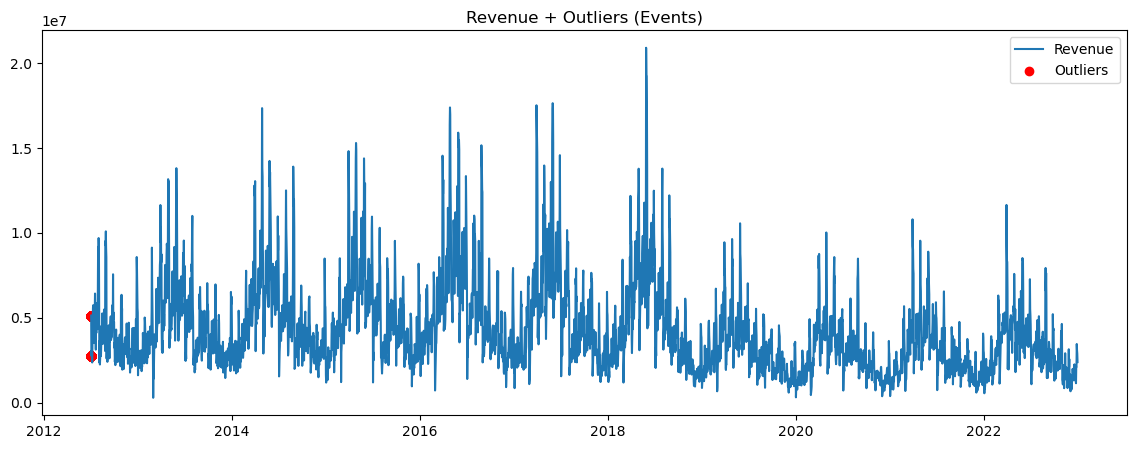

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

plt.plot(sales['date'], sales['revenue'], label='Revenue')

plt.scatter(
    sales.loc[sales['is_event_day'], 'date'],
    sales.loc[sales['is_event_day'], 'revenue'],
    color='red',
    label='Outliers'
)

plt.legend()
plt.title("Revenue + Outliers (Events)")
plt.show()

In [95]:
def build_daily_profit(df_orders, df_order_items, df_products, df_returns, df_shipments):

    # =========================================================
    # 1. CLEAN DATA
    # =========================================================
    df_orders      = df_orders.copy()
    df_order_items = df_order_items.copy()
    df_products    = df_products.copy()
    df_returns     = df_returns.copy()
    df_shipments   = df_shipments.copy()

    for df in [df_orders, df_order_items, df_products, df_returns, df_shipments]:
        df.columns = df.columns.str.strip().str.lower()

    df_orders['order_id']      = df_orders['order_id'].astype(str)
    df_order_items['order_id'] = df_order_items['order_id'].astype(str)
    df_shipments['order_id']   = df_shipments['order_id'].astype(str)
    df_returns['order_id']     = df_returns['order_id'].astype(str)
    df_returns['product_id']   = df_returns['product_id'].astype(str)

    df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
    df_orders['date']       = df_orders['order_date'].dt.date

    df_order_items['unit_price']      = pd.to_numeric(df_order_items['unit_price'],      errors='coerce')
    df_order_items['quantity']        = pd.to_numeric(df_order_items['quantity'],        errors='coerce')
    df_order_items['discount_amount'] = pd.to_numeric(df_order_items['discount_amount'], errors='coerce').fillna(0)
    df_products['cogs']               = pd.to_numeric(df_products['cogs'],               errors='coerce')
    df_shipments['shipping_fee']      = pd.to_numeric(df_shipments['shipping_fee'],      errors='coerce').fillna(0)
    df_returns['refund_amount']       = pd.to_numeric(df_returns['refund_amount'],       errors='coerce').fillna(0)

    # =========================================================
    # 2. SURROGATE KEY cho order_items
    #    — tránh duplicate khi join returns theo (order_id, product_id)
    # =========================================================
    df_order_items = df_order_items.reset_index(drop=True)
    df_order_items['item_key'] = df_order_items.index  # unique per row

    # =========================================================
    # 3. BASE MERGE
    # =========================================================
    ship_dedup = df_shipments[['order_id', 'shipping_fee']].drop_duplicates(subset='order_id')

    df = (
        df_order_items
        .merge(df_orders[['order_id', 'order_status', 'date']], on='order_id', how='left')
        .merge(df_products[['product_id', 'cogs']],             on='product_id', how='left')
        .merge(ship_dedup,                                       on='order_id', how='left')
    )
    df['shipping_fee'] = df['shipping_fee'].fillna(0)
    df['product_id']   = df['product_id'].astype(str)

    # =========================================================
    # 4. GMV ITEM + PHÂN BỔ SHIPPING
    # =========================================================
    df['gmv_item']  = df['unit_price'] * df['quantity']
    df['cogs_item'] = df['cogs']       * df['quantity']

    # Tổng GMV đơn (tính trên toàn bộ order_items gốc — chưa filter status)
    order_gmv = (
        df.groupby('order_id')['gmv_item']
        .sum()
        .rename('total_order_gmv')
        .reset_index()
    )
    df = df.merge(order_gmv, on='order_id', how='left')

    df['alloc_ratio']            = df['gmv_item'] / df['total_order_gmv'].replace(0, np.nan)
    df['allocated_shipping_fee'] = df['shipping_fee'] * df['alloc_ratio'].fillna(0)

    # =========================================================
    # 5. DELIVERED — GMV / COGS / PROMO / FWD SHIPPING
    # =========================================================
    delivered = df[df['order_status'] == 'delivered']

    gmv      = delivered.groupby('date')['gmv_item'].sum()
    cogs     = delivered.groupby('date')['cogs_item'].sum()
    promo    = delivered.groupby('date')['discount_amount'].sum()
    fwd_ship = delivered.groupby('date')['allocated_shipping_fee'].sum()

    # =========================================================
    # 6. RETURNED — REFUND + REVERSE LOGISTIC
    # =========================================================
    returned = df[df['order_status'] == 'returned'].copy()

    # --- 6a. Gộp returns theo (order_id, product_id) trước ---
    # Nếu 1 sản phẩm có nhiều return record → sum refund_amount
    # Điều này tránh việc 1 return khớp với nhiều item_key duplicate
    returns_agg = (
        df_returns
        .groupby(['order_id', 'product_id'])
        .agg(
            refund_amount  = ('refund_amount',  'sum'),
            return_reason  = ('return_reason',  'first'),  # lấy reason đầu tiên
            return_quantity= ('return_quantity', 'sum')
        )
        .reset_index()
    )

    # --- 6b. Match return với đúng 1 item_key ---
    # Với duplicate (order_id, product_id) trong order_items,
    # chỉ gán return cho dòng có quantity gần nhất với return_quantity
    returned_with_reason = returned.merge(
        returns_agg, on=['order_id', 'product_id'], how='left'
    )

    # Với các cặp (order_id, product_id) bị duplicate trong order_items,
    # chỉ giữ 1 dòng per (order_id, product_id) — dòng có quantity gần return_quantity nhất
    has_return_qty = returned_with_reason['return_quantity'].notna()

    # Tính khoảng cách quantity
    returned_with_reason['qty_diff'] = np.where(
        has_return_qty,
        (returned_with_reason['quantity'] - returned_with_reason['return_quantity']).abs(),
        np.nan
    )

    # Với mỗi (order_id, product_id) có return: chỉ giữ dòng gần nhất
    mask_has_return = returned_with_reason['return_reason'].notna()

    best_match = (
        returned_with_reason[mask_has_return]
        .sort_values('qty_diff')
        .drop_duplicates(subset=['order_id', 'product_id'], keep='first')
    )
    no_return = returned_with_reason[~mask_has_return]

    returned_clean = pd.concat([best_match, no_return], ignore_index=True)

    # --- 6c. Refund: dùng refund_amount từ returns table ---
    returned_clean['row_refund_amount'] = returned_clean['refund_amount'].fillna(0)

    # --- 6d. Reverse logistic cost ---
    company_fault  = ['not_as_described', 'defective', 'late_delivery']
    customer_fault = ['wrong_size', 'changed_mind']

    returned_clean['reverse_multiplier'] = np.select(
        [
            returned_clean['return_reason'].isin(company_fault),
            returned_clean['return_reason'].isin(customer_fault),
        ],
        [2.0, 1.0],
        default=0.0
    )
    returned_clean['row_reverse_logistic_cost'] = (
        returned_clean['allocated_shipping_fee'] * returned_clean['reverse_multiplier']
    )

    # --- 6e. Aggregate theo order_date ---
    refund       = returned_clean.groupby('date')['row_refund_amount'].sum()
    rev_logistic = returned_clean.groupby('date')['row_reverse_logistic_cost'].sum()

    # =========================================================
    # 7. COMBINE
    # =========================================================
    profit_df = pd.concat(
        [gmv, cogs, promo, fwd_ship, refund, rev_logistic],
        axis=1
    )
    profit_df.columns = ['gmv', 'cogs', 'promo', 'fwd_shipping', 'refund', 'reverse_cost']
    profit_df = profit_df.fillna(0)

    # =========================================================
    # 8. NET PROFIT & MARGIN
    # =========================================================
    profit_df['net_profit'] = (
        profit_df['gmv']
        - profit_df['cogs']
        - profit_df['promo']
        - profit_df['fwd_shipping']
        - profit_df['refund']
        - profit_df['reverse_cost']
    )
    profit_df['margin'] = np.where(
        profit_df['gmv'] == 0,
        0,
        profit_df['net_profit'] / profit_df['gmv']
    )

    profit_df.index.name = 'date'
    return profit_df.sort_index()

In [96]:
def export_profit(profit_df, folder="output_profit"):

    # =========================
    # 1. CREATE FOLDER
    # =========================
    os.makedirs(folder, exist_ok=True)

    # =========================
    # 2. RESET INDEX SAFELY
    # =========================
    out = profit_df.reset_index()

    # đảm bảo có cột date
    if 'date' not in out.columns:
        out.rename(columns={out.columns[0]: 'date'}, inplace=True)

    # =========================
    # 3. EXPORT FULL DATA
    # =========================
    full_path = os.path.join(folder, "daily_profit.csv")
    out.to_csv(full_path, index=False)

    # =========================
    # 4. EXPORT LOSS DAYS
    # =========================
    if 'net_profit' in out.columns:
        loss_path = os.path.join(folder, "loss_days.csv")
        out[out['net_profit'] < 0].to_csv(loss_path, index=False)

    # =========================
    # 5. PRINT INFO
    # =========================
    print("EXPORT COMPLETED")
    print("Folder:", os.path.abspath(folder))
    print("File:", full_path)

In [97]:
profit_df = build_daily_profit(
    orders, order_items, products, returns, shipments
)

export_profit(profit_df)

EXPORT COMPLETED
Folder: C:\Users\ASUS\Documents\DatathonData\output_profit
File: output_profit\daily_profit.csv


In [89]:
data = load_data("dataset/")

df_orders      = data['orders']
df_order_items = data['order_items']
df_products    = data['products']
df_returns     = data['returns']
df_shipments   = data['shipments']

# ============================================================
# DEBUG
# ============================================================

print("=== ORDER STATUS ===")
print(df_orders['order_status'].value_counts())

print("\n=== ĐƠN DELIVERED ===", df_orders[df_orders['order_status']=='delivered']['order_id'].nunique())
print("=== ĐƠN RETURNED  ===", df_orders[df_orders['order_status']=='returned']['order_id'].nunique())

print("\n=== RETURNS TABLE columns ===")
print(df_returns.columns.tolist())
print(df_returns.head(3))

print("\n=== SHIPMENTS DUPLICATE order_id ===")
ship_cnt = df_shipments.groupby('order_id').size()
print(ship_cnt[ship_cnt > 1].head(10))

print("\n=== ORDER_ITEMS DUPLICATE (order_id, product_id) ===")
items_cnt = df_order_items.groupby(['order_id','product_id']).size()
print(items_cnt[items_cnt > 1].head(10))

print("\n=== SPOT CHECK 1 đơn delivered ===")
sample_order = df_orders[df_orders['order_status']=='delivered']['order_id'].iloc[0]
print("order_id:", sample_order)
print(df_order_items[df_order_items['order_id']==sample_order][['product_id','quantity','unit_price','discount_amount']])
print(df_shipments[df_shipments['order_id']==sample_order][['shipping_fee']])
print(df_products[df_products['product_id'].isin(
      df_order_items[df_order_items['order_id']==sample_order]['product_id'])][['product_id','cogs']])

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34996\3435610155.py:24: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path + f)


=== ORDER STATUS ===
order_status
delivered    516716
cancelled     59462
returned      36142
shipped       13773
paid          13577
created        7275
Name: count, dtype: int64

=== ĐƠN DELIVERED === 516716
=== ĐƠN RETURNED  === 36142

=== RETURNS TABLE columns ===
['return_id', 'order_id', 'product_id', 'return_date', 'return_reason', 'return_quantity', 'refund_amount']
    return_id  order_id  product_id return_date  return_reason  \
0  RET-000001         2         609  2012-07-25  late_delivery   
1  RET-000002        32        1862  2012-07-16     wrong_size   
2  RET-000003        35        2359  2012-07-16     wrong_size   

   return_quantity  refund_amount  
0                6       52458.01  
1                2        5141.37  
2                1        5315.95  

=== SHIPMENTS DUPLICATE order_id ===
Series([], dtype: int64)

=== ORDER_ITEMS DUPLICATE (order_id, product_id) ===
order_id  product_id
14280     976           2
113379    786           2
215525    1859          

In [90]:
# Xem thử 1 case duplicate để hiểu data
dup = df_order_items[
    df_order_items.duplicated(subset=['order_id','product_id'], keep=False)
].sort_values(['order_id','product_id'])
print(dup.head(10))

# Tổng số dòng bị ảnh hưởng
print(f"\nTổng dòng duplicate: {df_order_items.duplicated(subset=['order_id','product_id'], keep=False).sum()}")
print(f"Tổng dòng order_items: {len(df_order_items)}")

        order_id  product_id  quantity  unit_price  discount_amount  \
12233      14280         976         1     4019.47             0.00   
12234      14280         976         2     3937.99             0.00   
99645     113379         786         6      694.34             0.00   
99646     113379         786         1      699.37             0.00   
189239    215525        1859         5     1896.11             0.00   
189240    215525        1859         5     1897.20             0.00   
190291    216740         791         8      793.10             0.00   
190292    216740         791         5      825.52             0.00   
214311    243342         777         7     1181.17          1653.64   
214312    243342         777         5     1147.21          1147.21   

          promo_id promo_id_2  
12233          NaN        NaN  
12234          NaN        NaN  
99645          NaN        NaN  
99646          NaN        NaN  
189239         NaN        NaN  
189240         NaN        

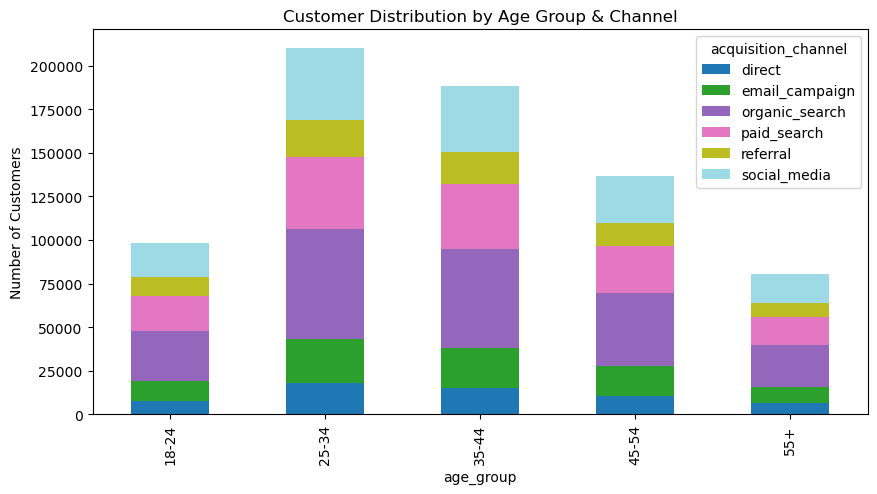

In [102]:
# group
df_grouped = df.groupby(["age_group", "acquisition_channel"]) \
               .size().reset_index(name="count")

# pivot
pivot = df_grouped.pivot(index="age_group",
                         columns="acquisition_channel",
                         values="count").fillna(0)

# plot stacked bar
pivot.plot(kind="bar", stacked=True, figsize=(10,5), colormap="tab20")

plt.title("Customer Distribution by Age Group & Channel")
plt.ylabel("Number of Customers")
plt.show()

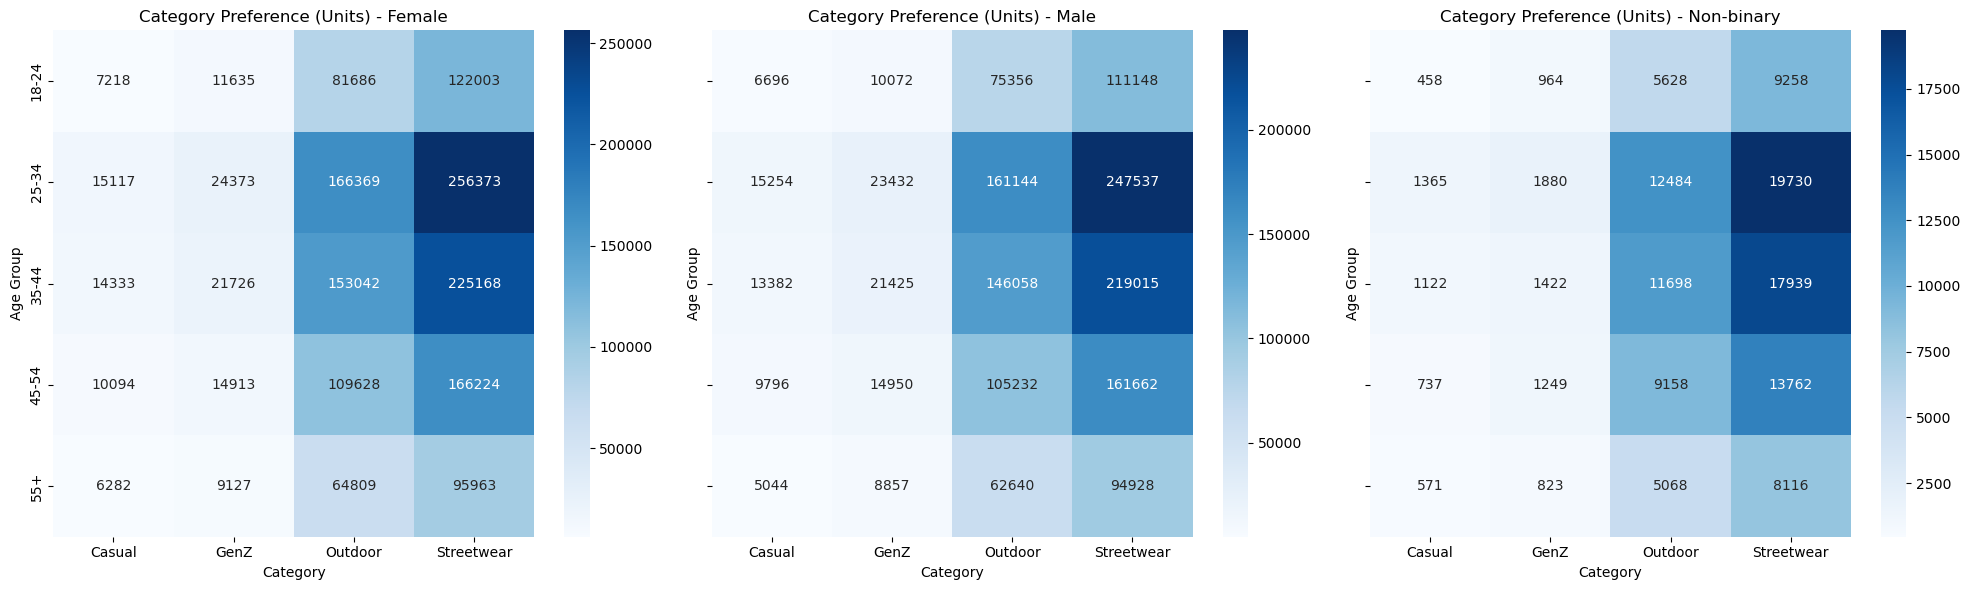

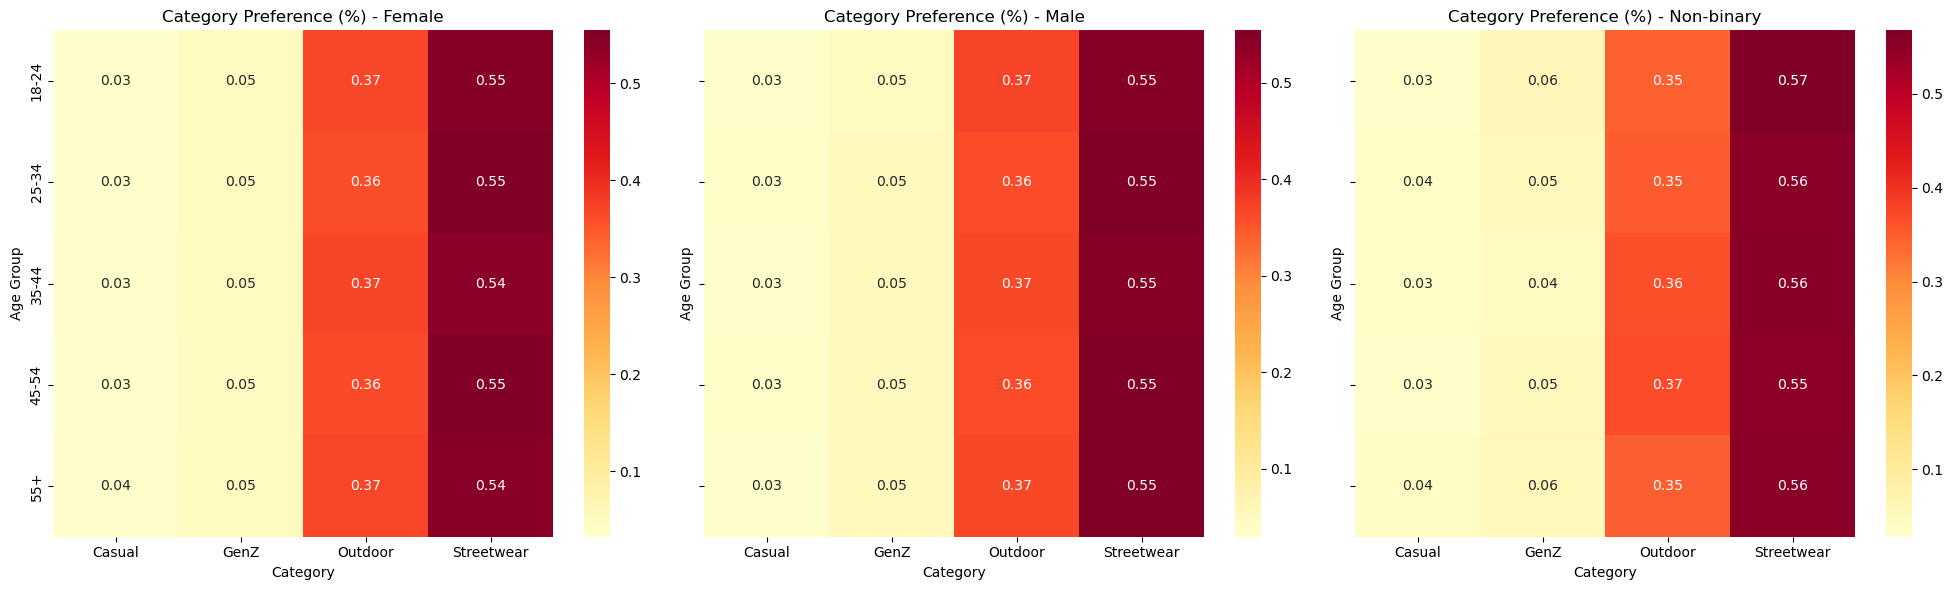

In [113]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# 1. MERGE DATA
# =========================
df = order_items.merge(products, on="product_id") \
                .merge(orders, on="order_id") \
                .merge(customers, on="customer_id")

# =========================
# 2. AGGREGATE (RAW COUNT)
# =========================
df_agg = df.groupby(
    ["gender", "age_group", "category"]
)["quantity"].sum().reset_index()

# =========================
# 3. CREATE PLOT STRUCTURE
# =========================
genders = df_agg["gender"].unique()

fig, axes = plt.subplots(1, len(genders), figsize=(20,6), sharey=True)

# nếu chỉ có 1 gender (tránh lỗi axes)
if len(genders) == 1:
    axes = [axes]

# =========================
# 4. PLOT RAW VOLUME HEATMAP
# =========================
for i, g in enumerate(genders):
    temp = df_agg[df_agg["gender"] == g]

    pivot = temp.pivot_table(
        index="age_group",
        columns="category",
        values="quantity",
        aggfunc="sum"
    ).fillna(0)

    sns.heatmap(
        pivot,
        cmap="Blues",
        annot=True,
        fmt=".0f",
        ax=axes[i]
    )

    axes[i].set_title(f"Category Preference (Units) - {g}")
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Age Group")

plt.tight_layout()
plt.show()

# =========================
# 5. AGGREGATE (PERCENT SHARE)
# =========================
df_pct = df_agg.copy()

df_pct["pct"] = df_pct.groupby(
    ["gender", "age_group"]
)["quantity"].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, len(genders), figsize=(20,6), sharey=True)

if len(genders) == 1:
    axes = [axes]

# =========================
# 6. PLOT SHARE HEATMAP
# =========================
for i, g in enumerate(genders):
    temp = df_pct[df_pct["gender"] == g]

    pivot = temp.pivot_table(
        index="age_group",
        columns="category",
        values="pct",
        aggfunc="sum"
    ).fillna(0)

    sns.heatmap(
        pivot,
        cmap="YlOrRd",
        annot=True,
        fmt=".2f",
        ax=axes[i]
    )

    axes[i].set_title(f"Category Preference (%) - {g}")
    axes[i].set_xlabel("Category")
    axes[i].set_ylabel("Age Group")

plt.tight_layout()
plt.show()

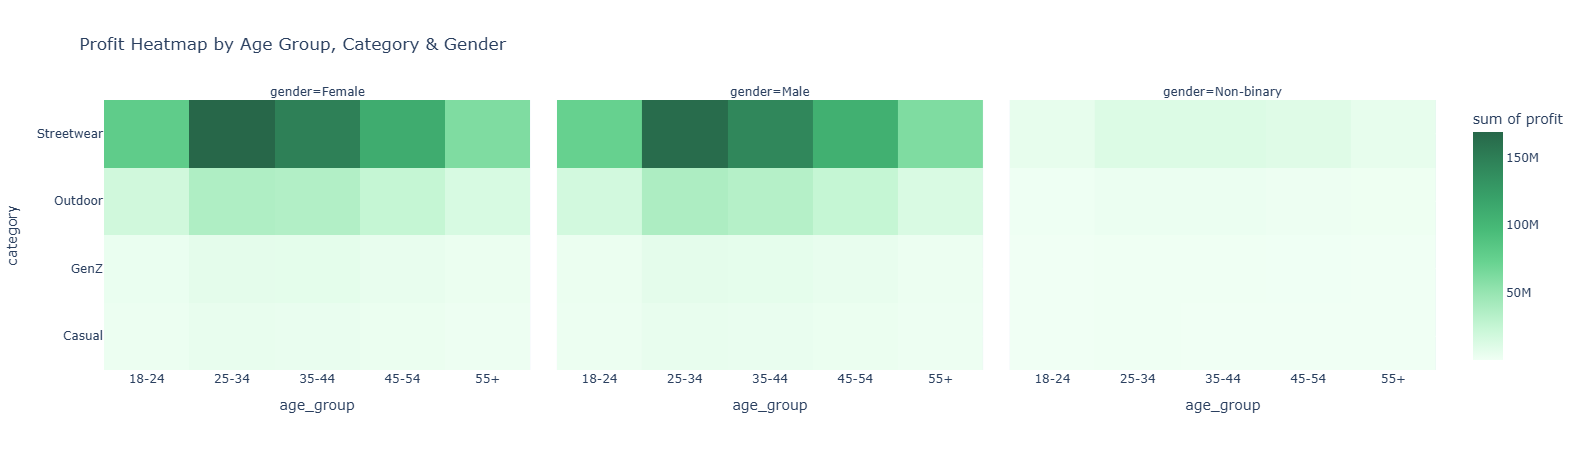

In [128]:
import plotly.express as px

df = order_items.merge(products, on="product_id") \
                .merge(orders, on="order_id") \
                .merge(customers, on="customer_id")

df["profit"] = (df["unit_price"] - df["cogs"]) * df["quantity"] - df["discount_amount"].fillna(0)

df_profit = df.groupby(["gender", "category", "age_group"])["profit"].sum().reset_index()

fig = px.density_heatmap(
    df_profit,
    x="age_group",
    y="category",
    z="profit",
    facet_col="gender",
    color_continuous_scale=[
        "#f0fff4",
        "#c6f6d5",
        "#9ae6b4",
        "#68d391",
        "#48bb78",
        "#38a169",
        "#2f855a",
        "#276749"
    ],
    title="Profit Heatmap by Age Group, Category & Gender"
)

fig.update_layout(height=450)
fig.show()

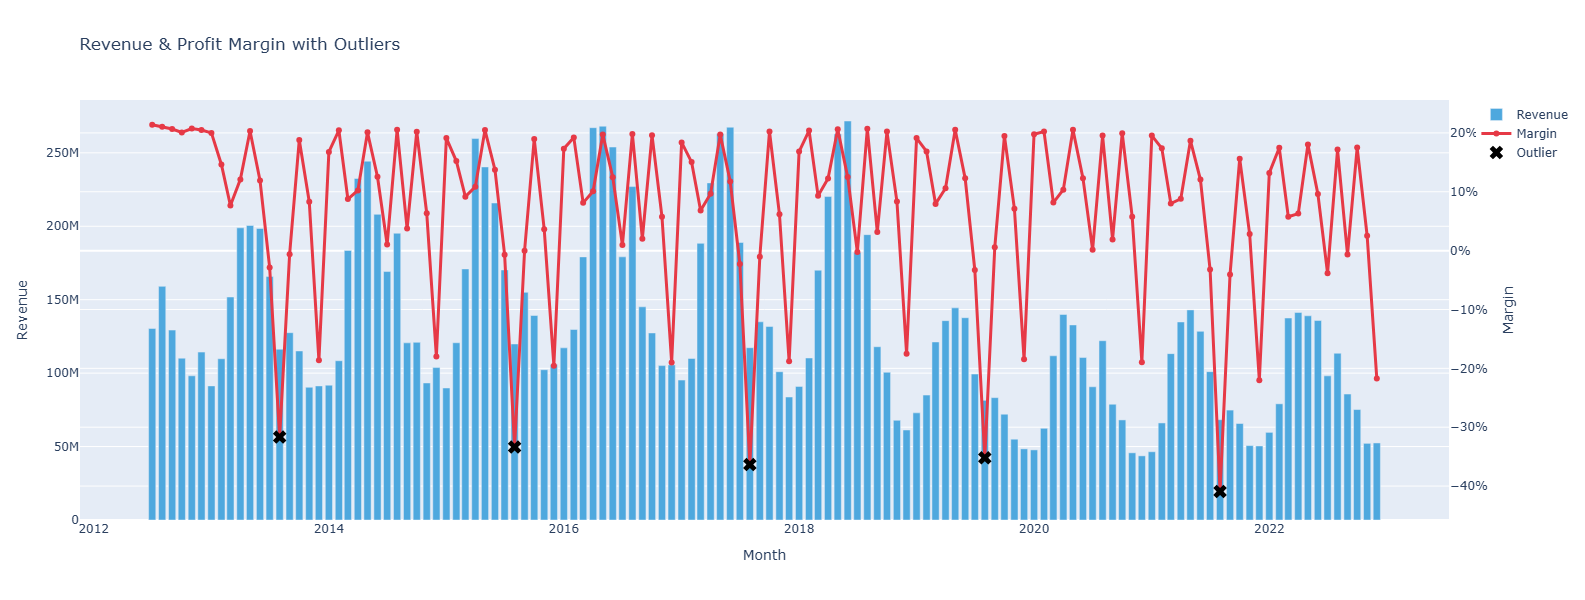

In [135]:
import pandas as pd
import plotly.graph_objects as go

# ===== DATA PREP =====
df = order_items.merge(products, on="product_id") \
                .merge(orders, on="order_id")

df["revenue"] = df["unit_price"] * df["quantity"]
df["cost"] = df["cogs"] * df["quantity"]
df["profit"] = df["revenue"] - df["cost"] - df["discount_amount"].fillna(0)

df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M").astype(str)

ts = df.groupby("month").agg(
    revenue=("revenue", "sum"),
    profit=("profit", "sum")
).reset_index()

ts["margin"] = ts["profit"] / ts["revenue"]

# ===== OUTLIER DETECTION (IQR) =====
Q1 = ts["margin"].quantile(0.25)
Q3 = ts["margin"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

ts["outlier"] = (ts["margin"] < lower) | (ts["margin"] > upper)

# ===== PLOT =====
fig = go.Figure()

# Revenue bar
fig.add_trace(go.Bar(
    x=ts["month"],
    y=ts["revenue"],
    name="Revenue",
    marker_color="#4ea8de"
))

# Margin line
fig.add_trace(go.Scatter(
    x=ts["month"],
    y=ts["margin"],
    name="Margin",
    mode="lines+markers",
    line=dict(color="#e63946", width=3),
    yaxis="y2"
))

# Highlight outliers
fig.add_trace(go.Scatter(
    x=ts[ts["outlier"]]["month"],
    y=ts[ts["outlier"]]["margin"],
    mode="markers",
    name="Outlier",
    marker=dict(color="black", size=12, symbol="x"),
    yaxis="y2"
))

# Layout
fig.update_layout(
    title="Revenue & Profit Margin with Outliers",
    xaxis=dict(title="Month"),
    yaxis=dict(title="Revenue"),
    yaxis2=dict(title="Margin", overlaying="y", side="right", tickformat=".0%"),
    height=600
)

fig.show()

In [136]:
import pandas as pd

df = order_items.merge(products, on="product_id") \
                .merge(orders, on="order_id")

df["revenue"] = df["unit_price"] * df["quantity"]
df["cost"] = df["cogs"] * df["quantity"]
df["profit"] = df["revenue"] - df["cost"] - df["discount_amount"].fillna(0)

df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M").astype(str)

ts = df.groupby("month").agg(
    revenue=("revenue", "sum"),
    cost=("cost", "sum"),
    discount=("discount_amount", "sum"),
    profit=("profit", "sum")
).reset_index()

ts["margin"] = ts["profit"] / ts["revenue"]

# IQR outlier
Q1 = ts["margin"].quantile(0.25)
Q3 = ts["margin"].quantile(0.75)
IQR = Q3 - Q1

ts["outlier"] = (ts["margin"] < Q1 - 1.5*IQR) | (ts["margin"] > Q3 + 1.5*IQR)

outlier_months = ts[ts["outlier"]]["month"]

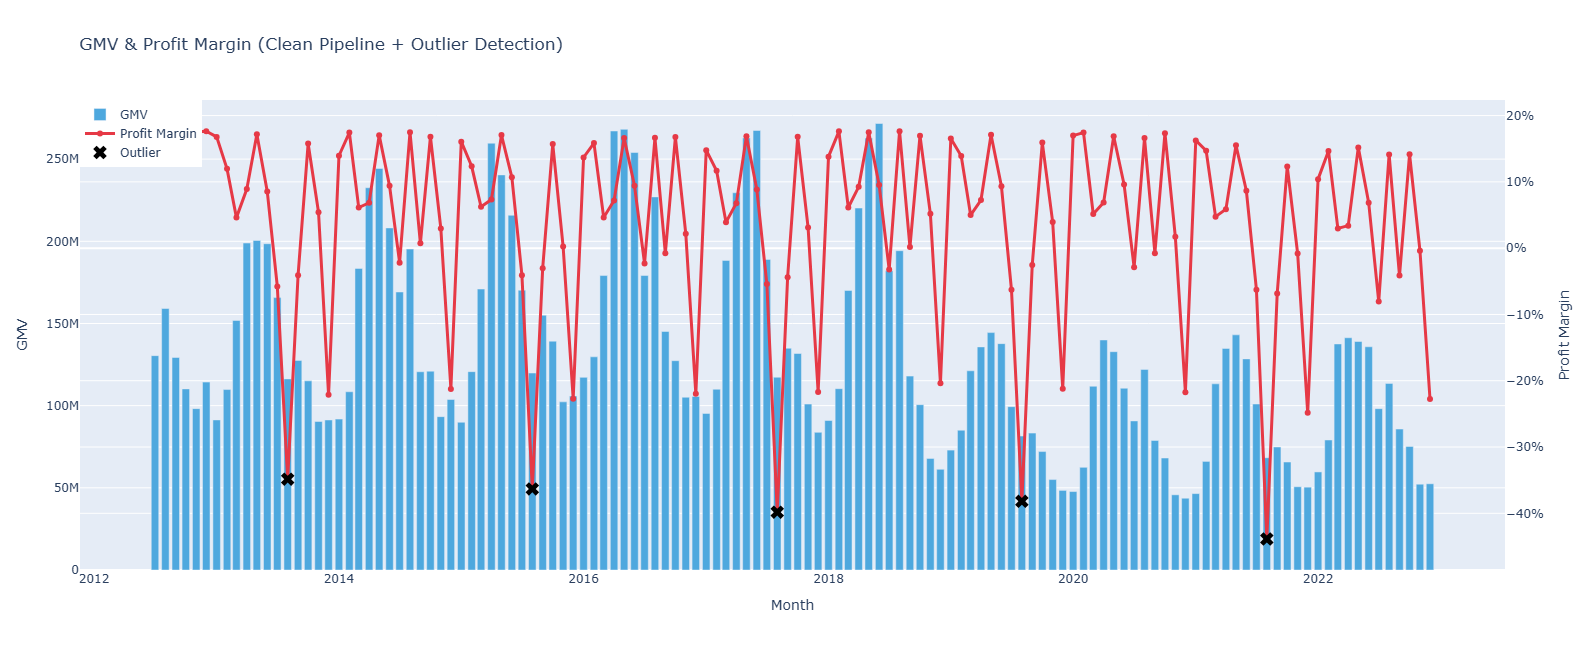

In [139]:
import pandas as pd
import plotly.graph_objects as go

# =========================
# 0. FIX DATA TYPE (QUAN TRỌNG NHẤT)
# =========================
# 🔴 FIX: đảm bảo key cùng kiểu dữ liệu trước khi merge
order_items["order_id"] = order_items["order_id"].astype(str)   # FIX HERE
order_items["product_id"] = order_items["product_id"].astype(str)  # FIX HERE

orders["order_id"] = orders["order_id"].astype(str)  # FIX HERE
products["product_id"] = products["product_id"].astype(str)  # FIX HERE

# =========================
# 1. MERGE DATA
# =========================
df = order_items.merge(products, on="product_id") \
                .merge(orders, on="order_id")

# =========================
# 2. GMV
# =========================
df["gmv"] = df["unit_price"] * df["quantity"]

# =========================
# 3. COST COMPONENTS
# =========================
df["cogs_total"] = df["cogs"] * df["quantity"]

df["promo_cost"] = df["discount_amount"].fillna(0)

# =========================
# 4. RETURNS (optional safe)
# =========================
if "returns" in globals():
    returns["order_id"] = returns["order_id"].astype(str)  # FIX HERE
    returns["product_id"] = returns["product_id"].astype(str)  # FIX HERE

    df = df.merge(returns, on=["order_id", "product_id"], how="left")
    df["refund_cost"] = df["refund_amount"].fillna(0)
else:
    df["refund_cost"] = 0

# =========================
# 5. REVERSE LOGISTICS (placeholder)
# =========================
df["reverse_logistics_cost"] = 0

# =========================
# 6. NET PROFIT + MARGIN
# =========================
df["net_profit"] = (
    df["gmv"]
    - df["cogs_total"]
    - df["promo_cost"]
    - df["refund_cost"]
    - df["reverse_logistics_cost"]
)

df["margin"] = df["net_profit"] / df["gmv"]

# =========================
# 7. TIME AGGREGATION
# =========================
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M").astype(str)

ts = df.groupby("month").agg(
    gmv=("gmv", "sum"),
    cogs=("cogs_total", "sum"),
    promo=("promo_cost", "sum"),
    refund=("refund_cost", "sum"),
    reverse=("reverse_logistics_cost", "sum"),
    profit=("net_profit", "sum")
).reset_index()

ts["margin"] = ts["profit"] / ts["gmv"]

# =========================
# 8. OUTLIER DETECTION (IQR)
# =========================
Q1 = ts["margin"].quantile(0.25)
Q3 = ts["margin"].quantile(0.75)
IQR = Q3 - Q1

ts["outlier"] = (ts["margin"] < Q1 - 1.5 * IQR) | (ts["margin"] > Q3 + 1.5 * IQR)

# =========================
# 9. PLOT
# =========================
fig = go.Figure()

# 📊 GMV BAR
fig.add_trace(go.Bar(
    x=ts["month"],
    y=ts["gmv"],
    name="GMV",
    marker_color="#4ea8de"
))

# 📈 MARGIN LINE
fig.add_trace(go.Scatter(
    x=ts["month"],
    y=ts["margin"],
    name="Profit Margin",
    mode="lines+markers",
    line=dict(color="#e63946", width=3),
    yaxis="y2"
))

# ❌ OUTLIER MARKERS
fig.add_trace(go.Scatter(
    x=ts[ts["outlier"]]["month"],
    y=ts[ts["outlier"]]["margin"],
    mode="markers",
    name="Outlier",
    marker=dict(color="black", size=12, symbol="x"),
    yaxis="y2"
))

# =========================
# 10. LAYOUT
# =========================
fig.update_layout(
    title="GMV & Profit Margin (Clean Pipeline + Outlier Detection)",
    xaxis=dict(title="Month"),

    yaxis=dict(title="GMV"),

    yaxis2=dict(
        title="Profit Margin",
        overlaying="y",
        side="right",
        tickformat=".0%"
    ),

    height=650,
    legend=dict(x=0, y=1)
)

fig.show()

In [142]:
cols = promotions.columns

for col in cols:
    print(f"\n===== {col} =====")
    print("Số lượng unique:", promotions[col].nunique())
    print(promotions[col].dropna().unique())

# Spring Sale
# Mid-Year Sale
# Fall Launch
# Year-end
#Rural Special


===== promo_id =====
Số lượng unique: 50
['PROMO-0001' 'PROMO-0002' 'PROMO-0003' 'PROMO-0004' 'PROMO-0005'
 'PROMO-0006' 'PROMO-0007' 'PROMO-0008' 'PROMO-0009' 'PROMO-0010'
 'PROMO-0011' 'PROMO-0012' 'PROMO-0013' 'PROMO-0014' 'PROMO-0015'
 'PROMO-0016' 'PROMO-0017' 'PROMO-0018' 'PROMO-0019' 'PROMO-0020'
 'PROMO-0021' 'PROMO-0022' 'PROMO-0023' 'PROMO-0024' 'PROMO-0025'
 'PROMO-0026' 'PROMO-0027' 'PROMO-0028' 'PROMO-0029' 'PROMO-0030'
 'PROMO-0031' 'PROMO-0032' 'PROMO-0033' 'PROMO-0034' 'PROMO-0035'
 'PROMO-0036' 'PROMO-0037' 'PROMO-0038' 'PROMO-0039' 'PROMO-0040'
 'PROMO-0041' 'PROMO-0042' 'PROMO-0043' 'PROMO-0044' 'PROMO-0045'
 'PROMO-0046' 'PROMO-0047' 'PROMO-0048' 'PROMO-0049' 'PROMO-0050']

===== promo_name =====
Số lượng unique: 50
['Spring Sale 2013' 'Mid-Year Sale 2013' 'Fall Launch 2013'
 'Year-End Sale 2013' 'Urban Blowout 2013' 'Rural Special 2013'
 'Spring Sale 2014' 'Mid-Year Sale 2014' 'Fall Launch 2014'
 'Year-End Sale 2014' 'Spring Sale 2015' 'Mid-Year Sale 2015'
 'Fall 

In [148]:
import pandas as pd

# =========================
# 1. MERGE DATA
# =========================
df = order_items.merge(products, on="product_id") \
                .merge(orders, on="order_id") \
                .merge(promotions, on="promo_id", how="left")

# =========================
# 2. METRICS
# =========================
df["gmv"] = df["unit_price"] * df["quantity"]
df["cogs_total"] = df["cogs"] * df["quantity"]
df["promo_cost"] = df["discount_amount"].fillna(0)

df["profit"] = df["gmv"] - df["cogs_total"] - df["promo_cost"]
df["margin"] = df["profit"] / df["gmv"]

# =========================
# 3. IN PHÂN TÍCH TỪNG LOẠI
# =========================

def analyze(col):
    print(f"\n========== {col.upper()} ==========")
    
    result = df.groupby(col).agg(
        orders=("order_id", "count"),
        avg_gmv=("gmv", "mean"),
        avg_discount=("promo_cost", "mean"),
        avg_margin=("margin", "mean")
    ).sort_values("avg_margin")
    
    print(result)
    
    # in thêm chênh lệch
    diff = result["avg_margin"].max() - result["avg_margin"].min()
    print(f"\n👉 Margin gap ({col}): {diff:.4f}")

# =========================
# 4. CHẠY TỪNG LOẠI PROMO
# =========================

for col in [
    "promo_type",
    "stackable_flag",
    "promo_channel",
    "min_order_value",
    "applicable_category"
]:
    analyze(col)


========== PROMO_TYPE ==========
            orders       avg_gmv  avg_discount  avg_margin
promo_type                                                
fixed        20950  17970.106983    225.610979   -0.615789
percentage  255366  19810.639597   2916.914429   -0.087465

👉 Margin gap (promo_type): 0.5283

========== STACKABLE_FLAG ==========
                orders       avg_gmv  avg_discount  avg_margin
stackable_flag                                                
0.0             202773  19325.631546   2714.644198   -0.155332
1.0              73543  20623.597722   2707.950072   -0.050846

👉 Margin gap (stackable_flag): 0.1045

========== PROMO_CHANNEL ==========
               orders       avg_gmv  avg_discount  avg_margin
promo_channel                                                
online          66171  21419.400099   2406.038540   -0.254995
social_media    31977  21552.029205   3879.365228   -0.145716
all_channels   127687  18346.560287   2791.888293   -0.103503
in_store         89